LEVEL 1: Data Exploration and Basic Operations

In [11]:
#Importing Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [12]:
#Task 1.1

dataset = input("Enter dataset (with .csv extension): ")
df = pd.read_csv(dataset)

print("\nFirst ten lines of the dataset:-")
print(df.head(10))

print(df.info())

print("\nMissing values are:-")
print(df.isnull().sum())


First ten lines of the dataset:-
   Train_No    Train_Name           Source_Station_Name  \
0       107  SWV-MAO-VLNK               SAWANTWADI ROAD   
1       108  VLNK-MAO-SWV                   MADGOAN JN.   
2       128  MAO-KOP SPEC                   MADGOAN JN.   
3       290  PALACE ON WH             DELHI-SAFDAR JANG   
4       401  BSB BHARATDA                    AURANGABAD   
5       421  LKO-SVDK FTR                   LUCKNOW JN.   
6       422  SVDK-LKO FTR  SHRI MATA VAISHNO DEVI KATRA   
7       477  FTR TRAIN NO                         SIRSA   
8       502  RJPB-UMB FTR        RAJENDRANAGAR TERMINAL   
9       504  PNBE-BTI FTR                     PATNA JN.   

             Destination_Station_Name       days  
0                         MADGOAN JN.   Saturday  
1                     SAWANTWADI ROAD     Friday  
2  CHHATRAPATI SHAHU MAHARAJ TERMINUS     Friday  
3                   DELHI-SAFDAR JANG  Wednesday  
4                        VARANASI JN.   Saturday  
5        S

In [13]:
#Task 1.2

print("\nTotal number of trains: ", len(df))

print("Number of unique source stations: ", df["Source_Station_Name"].nunique())

print("Number of unique destination stations: ", df["Destination_Station_Name"].nunique())

mcs = df["Source_Station_Name"].value_counts().head(1)
print("\nMost common source station:-")
print(mcs)

mcd = df["Destination_Station_Name"].value_counts().head(1)
print("\nMost common destination station:-")
print(mcd)


Total number of trains:  11113
Number of unique source stations:  921
Number of unique destination stations:  924

Most common source station:-
Source_Station_Name
CST-MUMBAI    513
Name: count, dtype: int64

Most common destination station:-
Destination_Station_Name
CST-MUMBAI    514
Name: count, dtype: int64


In [14]:
#Task 1.3

df = df.dropna(subset=["Source_Station_Name", "Destination_Station_Name"])
df["Train_Name"] = df["Train_Name"].fillna("Unknown")
df["days"]= df["days"].fillna("Not Available")

df["Source_Station_Name"] = df["Source_Station_Name"].str.upper().str.strip()
df["Destination_Station_Name"] = df["Destination_Station_Name"].str.upper().str.strip()
df["Train_Name"] = df["Train_Name"].str.upper().str.strip()

print("\nMissing values after cleaning:-")
print(df.isnull().sum())

print("\nFirst ten lines of the cleaned dataset:-")
print(df.head(10))

df.to_csv("cleaned_Railway_info.csv", index=False)
print("\nCleaned dataset saved as 'cleaned_Railway_info.csv'")


Missing values after cleaning:-
Train_No                    0
Train_Name                  0
Source_Station_Name         0
Destination_Station_Name    0
days                        0
dtype: int64

First ten lines of the cleaned dataset:-
   Train_No    Train_Name           Source_Station_Name  \
0       107  SWV-MAO-VLNK               SAWANTWADI ROAD   
1       108  VLNK-MAO-SWV                   MADGOAN JN.   
2       128  MAO-KOP SPEC                   MADGOAN JN.   
3       290  PALACE ON WH             DELHI-SAFDAR JANG   
4       401  BSB BHARATDA                    AURANGABAD   
5       421  LKO-SVDK FTR                   LUCKNOW JN.   
6       422  SVDK-LKO FTR  SHRI MATA VAISHNO DEVI KATRA   
7       477  FTR TRAIN NO                         SIRSA   
8       502  RJPB-UMB FTR        RAJENDRANAGAR TERMINAL   
9       504  PNBE-BTI FTR                     PATNA JN.   

             Destination_Station_Name       days  
0                         MADGOAN JN.   Saturday  
1         

LEVEL 2: Data Transformation and Aggregation

In [15]:
#Task 2.1

df["days"]= df["days"].str.strip()
day_mapping = {
    "MON": "Monday",
    "TUE": "Tuesday",
    "WED": "Wednesday",
    "THU": "Thursday",
    "FRI": "Friday",
    "SAT": "Saturday",
    "SUN": "Sunday",
}
day_input = input("\nEnter a day of the week (first 3 letters only, e.g., MON, TUE, ...): ").upper().strip()
if day_input in day_mapping:
    full_day = day_mapping[day_input]
    filtered_trains = df[df["days"].str.contains(full_day, na=False)]
    print(f"\nTrains running on {full_day}:")
    print(filtered_trains[["Train_Name", "Source_Station_Name", "Destination_Station_Name"]])


Trains running on Thursday:
         Train_Name      Source_Station_Name Destination_Station_Name
13     PNBE-ASR FTR                PATNA JN.             AMRITSAR JN.
14      CSMT-NGP SF               CST-MUMBAI           NAGPUR JN.(CR)
17     LTT-KRMI SPL  LOKMANYA TILAK TERMINUS                  KARMALI
29     JBP-ATT BI-W                 JABALPUR                 ATARI JN
35      REWA-BPL SF                     REWA                   BHOPAL
...             ...                      ...                      ...
11082  PUNE-LNL EMU             SHIVAJINAGAR                  LONAVLA
11085  LNL-PUNE EMU                  LONAVLA                 PUNE JN.
11088  PUNE-LNL EMU                 PUNE JN.                  LONAVLA
11102  PUNE-LNL EMU                 PUNE JN.                  LONAVLA
11111           EMU                 TALEGAON                 PUNE JN.

[1526 rows x 3 columns]


In [16]:
#Task 2.2

trains_per_station = df.groupby('Source_Station_Name').size()
print("\nNumber of trains originating from each station:")
print(trains_per_station.head(10))

station_day_counts = df.groupby(['Source_Station_Name', 'days']).size()
avg_trains_per_day = station_day_counts.groupby('Source_Station_Name').mean()
print("\nAverage number of trains per day for each station:")
print(avg_trains_per_day.head(10))


Number of trains originating from each station:
Source_Station_Name
ABHANPUR JN.     2
ABOHAR           1
ABU ROAD         1
ACHHNERA JN.     1
ADILABAD         5
ADRA            16
ADRAJ MOTI       2
AGARTALA         8
AGRA  FORT       6
AGRA CANTT      16
dtype: int64

Average number of trains per day for each station:
Source_Station_Name
ABHANPUR JN.    1.000000
ABOHAR          1.000000
ABU ROAD        1.000000
ACHHNERA JN.    1.000000
ADILABAD        1.250000
ADRA            2.285714
ADRAJ MOTI      2.000000
AGARTALA        2.000000
AGRA  FORT      1.200000
AGRA CANTT      1.777778
dtype: float64


In [17]:
#Task 2.3

weekday = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
weekend = ['Saturday', 'Sunday']
df['Day_Type'] = 'Unknown'

df.loc[df['days'].isin(weekday), 'Day_Type'] = 'Weekday'
df.loc[df['days'].isin(weekend), 'Day_Type'] = 'Weekend'

print("\nData with Day_Type column:")
print(df[['days', 'Day_Type']].head(10))
df.to_csv("categorized_trains.csv", index=False)
print("\nFile saved as 'categorized_trains.csv'")


Data with Day_Type column:
        days Day_Type
0   Saturday  Weekend
1     Friday  Weekday
2     Friday  Weekday
3  Wednesday  Weekday
4   Saturday  Weekend
5    Tuesday  Weekday
6     Monday  Weekday
7     Sunday  Weekend
8     Monday  Weekday
9  Wednesday  Weekday

File saved as 'categorized_trains.csv'


LEVEL 3: Advanced Data Analysis

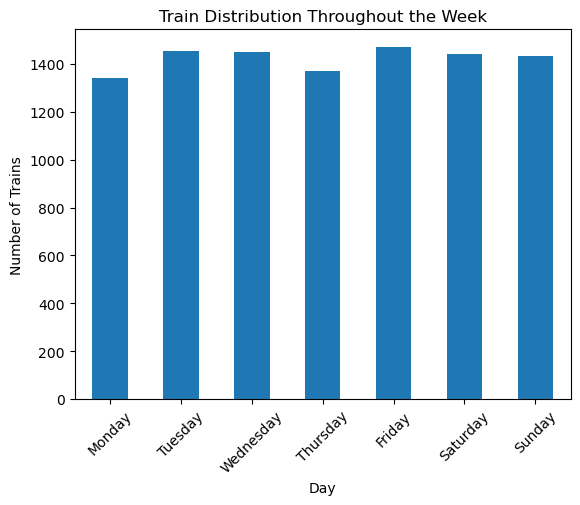


Top 10 Most Frequent Routes:
     Source_Station_Name Destination_Station_Name  Count
928        CHENNAI BEACH                 TAMBARAM    137
4400            TAMBARAM            CHENNAI BEACH    137
1127          CST-MUMBAI                   PANVEL     94
3490              PANVEL               CST-MUMBAI     93
3892            RAVLI JN               CST-MUMBAI     90
1129          CST-MUMBAI                 RAVLI JN     90
4716          VELACHEERY            CHENNAI BEACH     89
932        CHENNAI BEACH               VELACHEERY     87
1132          CST-MUMBAI                    THANE     77
4443               THANE               CST-MUMBAI     72


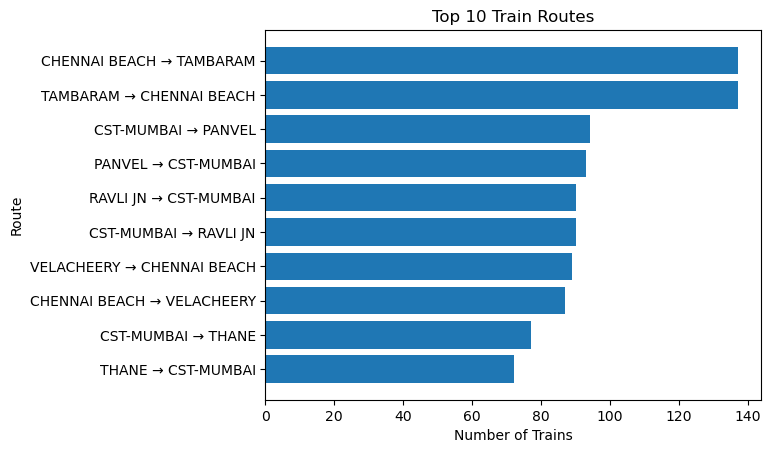

In [18]:
#Task 3.1

day_counts = df['days'].value_counts()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = day_counts.reindex(days_order)

plt.figure()
day_counts.plot(kind='bar')
plt.title("Train Distribution Throughout the Week")
plt.xlabel("Day")
plt.ylabel("Number of Trains")
plt.xticks(rotation=45)
plt.show()

route_counts = df.groupby(['Source_Station_Name', 'Destination_Station_Name']).size().reset_index(name='Count')
top_routes = route_counts.sort_values(by='Count', ascending=False).head(10)
print("\nTop 10 Most Frequent Routes:")
print(top_routes)

plt.figure()
plt.barh(
    top_routes['Source_Station_Name'] + " → " + top_routes['Destination_Station_Name'],
    top_routes['Count']
)
plt.title("Top 10 Train Routes")
plt.xlabel("Number of Trains")
plt.ylabel("Route")
plt.gca().invert_yaxis()
plt.show()


Number of trains per day:
days
Monday       1342
Tuesday      1454
Wednesday    1448
Thursday     1372
Friday       1471
Saturday     1441
Sunday       1432
Name: count, dtype: int64


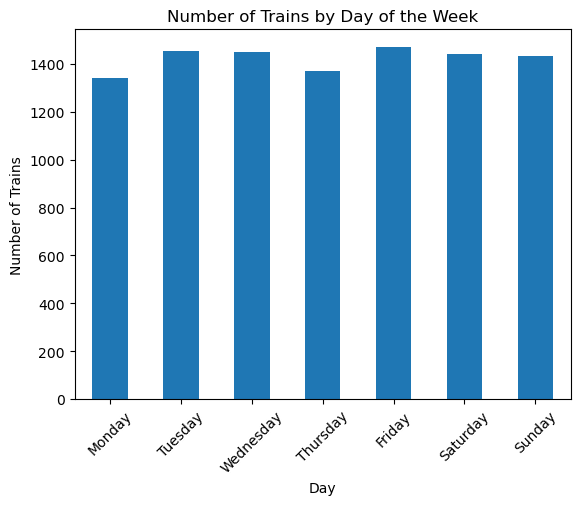

In [19]:
#Task 3.2

day_counts = df['days'].value_counts()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = day_counts.reindex(days_order)
print("\nNumber of trains per day:")
print(day_counts)

# Visualization
plt.figure()
day_counts.plot(kind='bar')
plt.title("Number of Trains by Day of the Week")
plt.xlabel("Day")
plt.ylabel("Number of Trains")
plt.xticks(rotation=45)
plt.show()

LEVEL 4: Data Visualization and Reporting

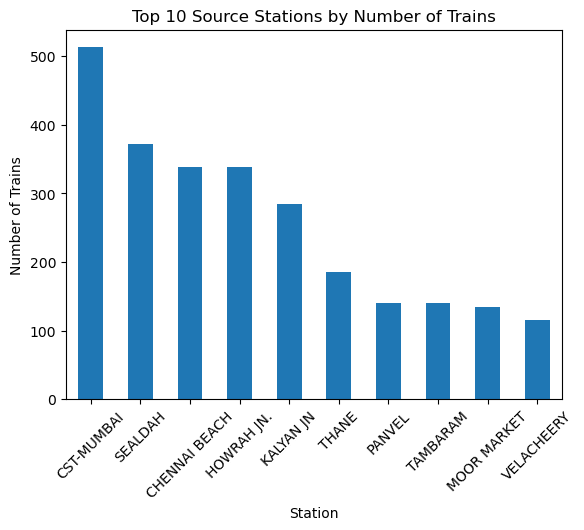

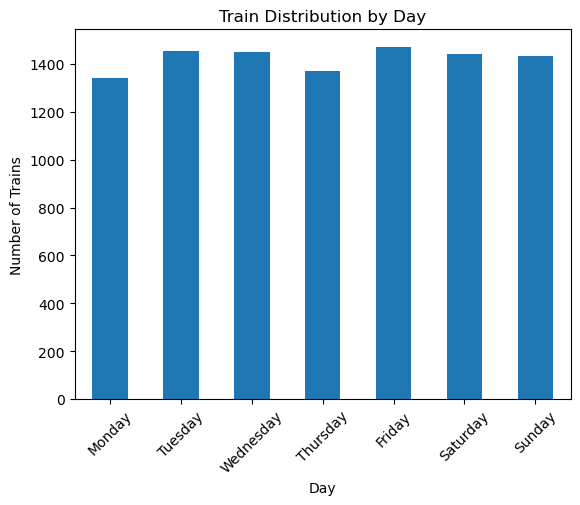

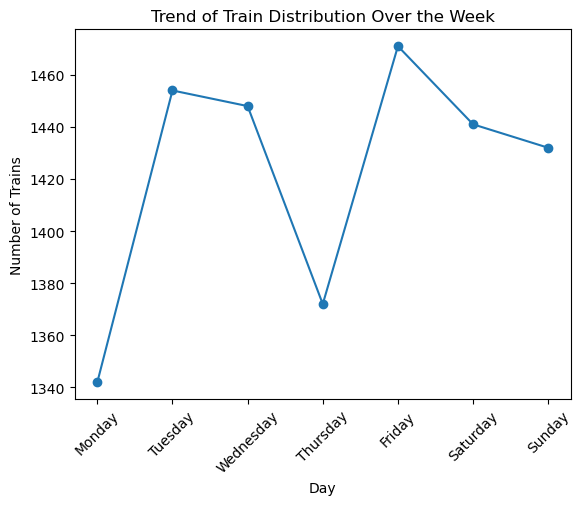

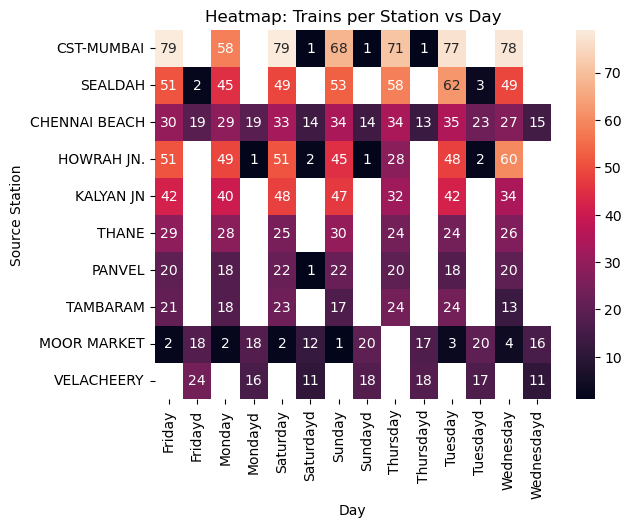

In [20]:
#Task 4.1

# 1. Bar Chart: Trains per Source Station
top_stations = df['Source_Station_Name'].value_counts().head(10)
plt.figure()
top_stations.plot(kind='bar')
plt.title("Top 10 Source Stations by Number of Trains")
plt.xlabel("Station")
plt.ylabel("Number of Trains")
plt.xticks(rotation=45)
plt.show()


# 2. Bar Chart: Day-wise Distribution
day_counts = df['days'].value_counts()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = day_counts.reindex(days_order)
plt.figure()
day_counts.plot(kind='bar')
plt.title("Train Distribution by Day")
plt.xlabel("Day")
plt.ylabel("Number of Trains")
plt.xticks(rotation=45)
plt.show()


# 3. Line Chart: Day-wise Trend
plt.figure()
plt.plot(day_counts.index, day_counts.values, marker='o')
plt.title("Trend of Train Distribution Over the Week")
plt.xlabel("Day")
plt.ylabel("Number of Trains")
plt.xticks(rotation=45)
plt.show()


# 4. Heatmap: Source Station vs Day
pivot_table = pd.pivot_table(
    df,
    values='Train_No',
    index='Source_Station_Name',
    columns='days',
    aggfunc='count'
)
top10 = df['Source_Station_Name'].value_counts().head(10).index
pivot_table = pivot_table.loc[top10]
plt.figure()
sns.heatmap(pivot_table, annot=True, fmt='g')
plt.title("Heatmap: Trains per Station vs Day")
plt.xlabel("Day")
plt.ylabel("Source Station")
plt.show()